# Compute the AMOC time series

In [5]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## 0) define functions

In [36]:
def calc_overturning_strength(da, freq_input, freq_output, basin_choice='atlantic_arctic_ocean', lat_choice=26.5, min_depth_choice=300):

    # get the unit
    unit = da.units
    
    # treat the basin names for better consistency across models
    if 'sector' in da.coords:
        sector_clean = np.char.decode(da.sector.values, "utf-8")
        sector_clean = np.char.strip(sector_clean)
        print(sector_clean)
        da = da.assign_coords(basin=("basin", sector_clean))    
    elif 'basin' in da.coords:
        print(da.basin.values)
        try:
            sector_clean = np.char.decode(da.basin.values, "utf-8")
            sector_clean = np.char.strip(sector_clean)
        except:
            sector_clean = da.basin.values
        da = da.assign_coords(basin=("basin", sector_clean))            

    # make basin an index to choose from and then choose from it
    if "basin" in da.coords:
        bbs = da.basin
        da = da.set_index(basin="basin")
    da = da.sel(basin=basin_choice)
    
    # mask out values
    da2 = xr.where(da<1e35,da,np.nan)

    # get the latitude dimension and choose the latitude
    if "lat" in da.coords:
        latdim = "lat"
        da3 = da2.sel(lat=lat_choice,method='nearest')
    elif "latitude" in da.coords:
        latdim = "latitude"
        da3 = da2.sel(latitude=lat_choice,method='nearest')
    else:
        print(da.dims)
        raise Exception('No known latitude dim.')
        
    # adjust time to freq_output
    if freq_input != freq_output:
        print('Need to adjust the time axis...')
        da4 = TimeOperator.calc_temporal_mean_weighted(da3,dim="time",freq_output=freq_output,          # None, "monthly", "yearly", "climatology"
        weights=None,
        skip_if_native=True,
        verbosity=1).compute()

    # now compute the overturning time series
    print('get time series')

    if "lev" in da.dims:
        levdim = "lev"
        overturning = da4.sel(lev=slice(min_depth_choice,10000)).max(dim='lev')
    elif "olevel" in da.dims:
        levdim = "olevel"
        overturning = da4.sel(olevel=slice(min_depth_choice,10000)).max(dim='olevel')

    print(lat_choice)
    lat_string = str(lat_choice).replace('.','p')
    overturning.name = f"amoc_at_{lat_string}"
    overturning.attrs['units'] = unit

    return overturning


## 1) get the varias, models and runs over which to do computation

In [37]:
lat_choice = 26.5
min_depth_choice = 300
basin_choice = 'atlantic_arctic_ocean'

freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
freq_output = 'yearly'
#varias = ['msftyz']#['msftyz']#,'msftmz']
models = ['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['NorESM2-LM']##['IPSL-CM6-ESMCO2']#,'NorESM2-LM','GFDL-ESM2M'] # ,['GFDL-ESM2M']#
runs = pruns.get_run_list('tipmip_tier1')[1:2]#[:1]#[1:]#[1:2]#[:1]#[1:]#[-1:] #

def get_varia(model):
    if model in ['IPSL-CM6-ESMCO2','GFDL-ESM2M']:
        varia = 'msftyz'
    elif model in ['NorESM2-LM']:
        varia = 'msftmz'
    else:
        raise Exception('Varia not yet chosen for this model.')
    return varia

## 2) loop over models and runs to do the computation, plotting and saving

Processing data for msftyz, IPSL-CM6-ESMCO2, esm-up2p0...
... loading 7080 data points in time.
['atlantic_arctic_ocean' 'indian_pacific_ocean' 'global_ocean']
<xarray.DataArray 'msftyz' (time: 7080, lev: 75, lat: 332)>
dask.array<getitem, shape=(7080, 75, 332), dtype=float32, chunksize=(1, 75, 332), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 1850-01-16 12:00:00 ... 2439-12-16 12:00:00
    sector   |S21 dask.array<chunksize=(), meta=np.ndarray>
  * lev      (lev) float64 0.5058 1.556 2.668 ... 5.495e+03 5.698e+03 5.902e+03
  * lat      (lat) float64 -84.22 -84.1 -83.97 -83.85 ... 89.15 89.37 89.37
    basin    <U21 'atlantic_arctic_ocean'
Attributes:
    standard_name:  ocean_y_overturning_mass_streamfunction
    long_name:      Ocean Y Overturning Mass Streamfunction
    comment:        Overturning mass streamfunction arising from all advectiv...
    units:          kg s-1
    original_name:  zomsfatl
    cell_methods:   time: mean longitude: mean
    history:   

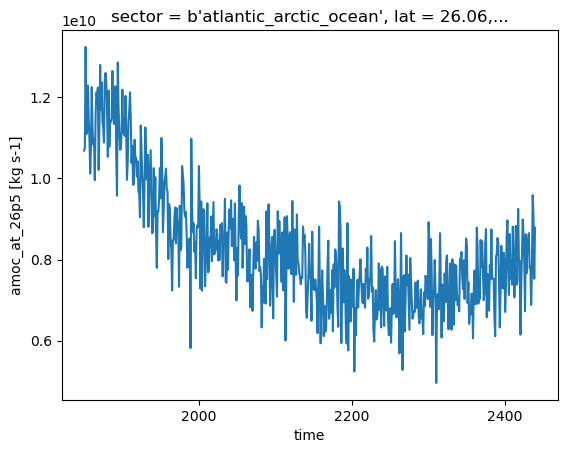

In [35]:
for model in models:
    varia = get_varia(model)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    
    global_stats = dict()
    for run in runs:
        print(f'Processing data for {varia}, {model}, {run}...')
        
        # first get the dataset
        #print('... loading ...')
        da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=0)#.compute()
        print(f'... loading {da.time.size} data points in time.')

        # now calculate the overturning
        overturning = calc_overturning_strength(da, freq_input, freq_output, basin_choice=basin_choice, lat_choice=lat_choice, min_depth_choice=min_depth_choice)
        lat_string = str(lat_choice).replace('.','p')

        # now save the data
        save_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_output}'
        os.makedirs(save_dir,exist_ok=True)
        save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_{freq_output}_{basin_choice}_{lat_string}_{min_depth_choice}m.nc'
        print(f'... saving under {save_string}')
        overturning.to_netcdf(save_string)#,encoding=encoding)
        
        # keep in a local dictionary for plotting
        global_stats[run] = overturning

        #for key in global_stats.keys():
        print(f'... plotting {run}')
        global_stats[run].plot()
        print(' ')
    plt.show()
